In [1]:
import astromugs as mugs
import astromugs.pipeline as pipeline
import astromugs.plotting.plot as mplt

/home/fmeyer/Stage/astroMUGS/astromugs/plotting/plot.py:1984: SyntaxWarning: invalid escape sequence '\p'
  """
/home/fmeyer/Stage/astroMUGS/astromugs/plotting/plot.py:2553: SyntaxWarning: invalid escape sequence '\p'
  """
/home/fmeyer/Stage/astroMUGS/astromugs/plotting/plot.py:2662: SyntaxWarning: invalid escape sequence '\p'
  """
/home/fmeyer/Stage/astroMUGS/astromugs/plotting/plot.py:2961: SyntaxWarning: invalid escape sequence '\m'
  """
/home/fmeyer/Stage/astroMUGS/astromugs/plotting/plot.py:3626: SyntaxWarning: invalid escape sequence '\c'
  """
/home/fmeyer/Stage/astroMUGS/astromugs/plotting/plot.py:3960: SyntaxWarning: invalid escape sequence '\p'
  """


In [2]:
import radmc3dPy as r3d

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os
import re
from matplotlib.collections import PolyCollection

In [4]:
MOLEC = ["CO","CN","CS","HCN","HCO+","N2H+","CH3OH","H2CO"]  

In [5]:
# PATHS
MODEL = ["Model23","Model33"]
CHEM_PATH = [Path("/home/fmeyer/Stage/"+mod+"/chemistry_final/") for mod in MODEL]
THERM_PATH = ["/home/fmeyer/Stage/"+mod+"/thermal/"  for mod in MODEL]
MODEL_NAMES = [f"Model {MOD[-2:]}" for MOD in MODEL]

In [6]:
print("="*100)
for i in range(len(MODEL)):
    M = int(MODEL[i][-2])
    a = int(MODEL[i][-1])
    print(f' ID : {i} | Model : {MODEL[i][-2:]} | M_disk = 10^-{M} M_sun | alpha = 10^-{a}')
print("="*100)

 ID : 0 | Model : 23 | M_disk = 10^-2 M_sun | alpha = 10^-3
 ID : 1 | Model : 33 | M_disk = 10^-3 M_sun | alpha = 10^-3


In [7]:
PIPE = []
for i in range(len(MODEL)):
    pipe = pipeline.Interface()
    pipe.add_chemical_path(CHEM_PATH[i])  # path to the chemistry directory
    pipe.add_thermal_path(THERM_PATH[i])  # path to thermal directory
    pipe.add_chemistry()
    PIPE.append(pipe)

In [8]:
class ListSizeCompatibilityError(Exception):
    """Exception raised if two lists are not compatible because of their size."""
    pass

# Plotting Nautilus outputs

<div class="alert alert-block alert-warning" style="font-size: 17px; line-height: 1.6em;">
    <b>⚠️ BE CAREFUL :</b><br>
    In all of the following functions:
    <ul>
        <li><code>PIPE</code> must be a list</li>
        <li><code>MODEL_NAMES</code> must be a list</li>
    </ul>
    Even if you have one model, you must write:
    <pre style="background-color: rgba(0,0,0,0.05); padding: 6px; margin-top: 10px; border-radius: 4px;"><code>PIPE = ["your_model"]
MODEL_NAMES = ["model_name"]</code></pre>
</div>

In [9]:
# FINDING THE LAST COMMON TIME STEP INDEX

# Time axis in years
yr = 365.25 * 24 * 3600
all_lists = []
for k in range(len(MODEL)):
    lists = [PIPE[k].chemistry[i]['time'] for i in list(PIPE[k].chemistry.keys())]
    all_lists = all_lists + lists
# for i in list(pipe.chemistry.keys()):
#     print((pipe.chemistry[i]['time'][-1]/yr))
sets = [set(l) for l in all_lists[1:]]

last_common_time = None
for t in reversed(all_lists[0]):
    if all(t in s for s in sets):
        last_common_time = t
        break

print(f"The last common time is : {(last_common_time/yr):.2e} yr")
i_last_time = np.where(pipe.chemistry[10]['time']==last_common_time)[0][0]
print(i_last_time)

The last common time is : 1.00e+00 yr
0


In [10]:
i_last_time = 22
print(f"t = {(pipe.chemistry[10]['time'][i_last_time]/(365.25*86400)):.0f} yrs")

t = 232 yrs


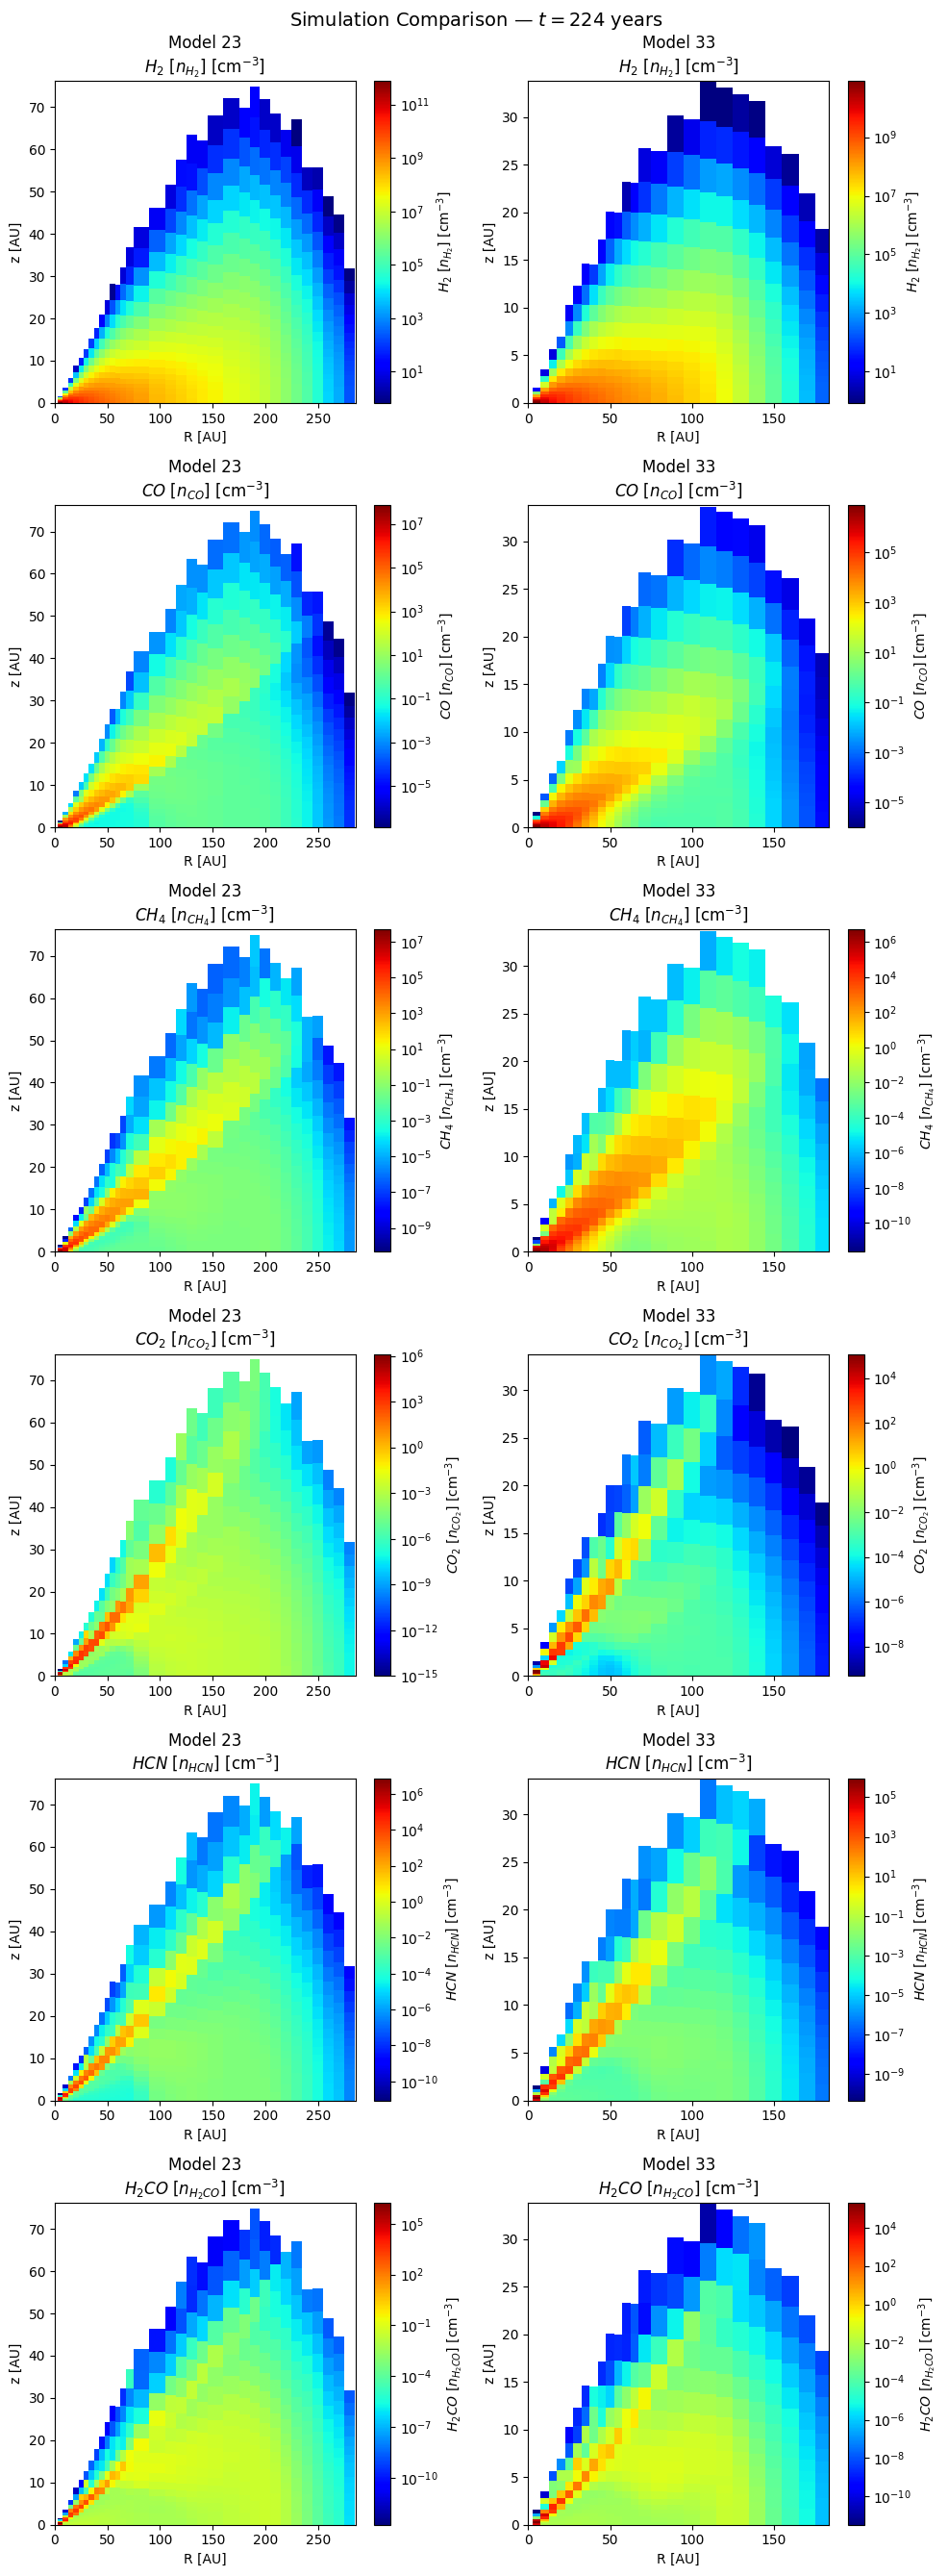

In [11]:
# SPECIES XX ABUNDANCES
mplt.plot_outputs_nautilus(PIPE,
                      MODEL_NAMES,
                      itime=i_last_time,
                      MODE='chemistry',
                      key_list=["H2","CO","CH4","CO2","HCN","H2CO"],
                      fracab=False,
                      verbose=True,
                      xlim=None,
                      ylim=None,
                      colormap="jet",
                      # res_colormap="jet",
                      vmin=None,
                      vmax=None,
                      common_scale=False)

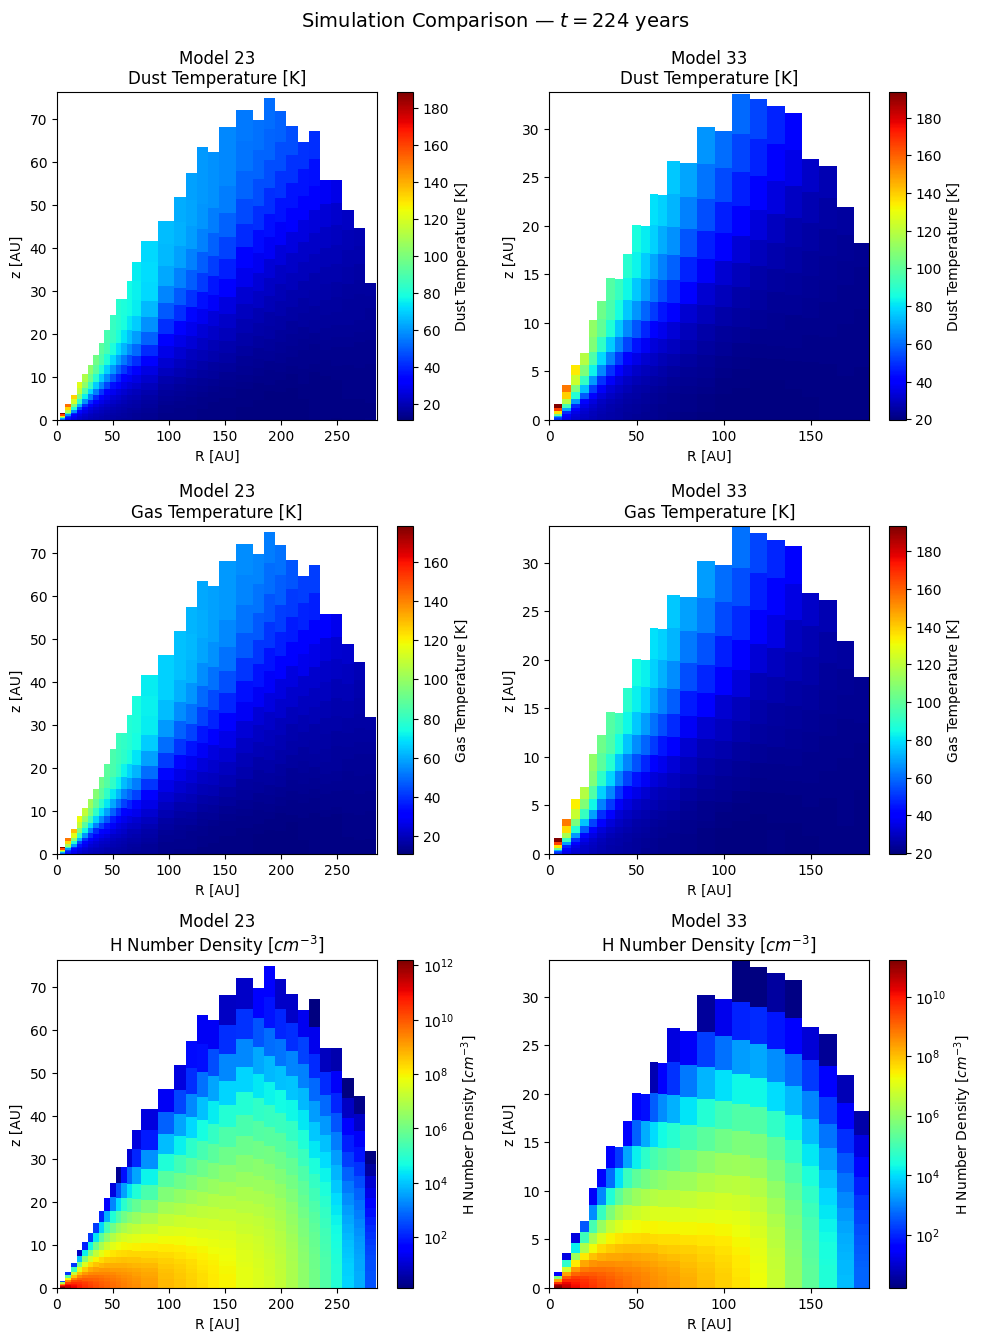

In [12]:
# PHYSICAL DATA
mplt.plot_outputs_nautilus(PIPE,
                      MODEL_NAMES,
                      itime=i_last_time,
                      MODE='physical',
                      key_list=['dust_temperature','gas_temperature', 'H_number_density'],
                      fracab=False,
                      verbose=True,
                     colormap='jet',
                     common_scale=False)

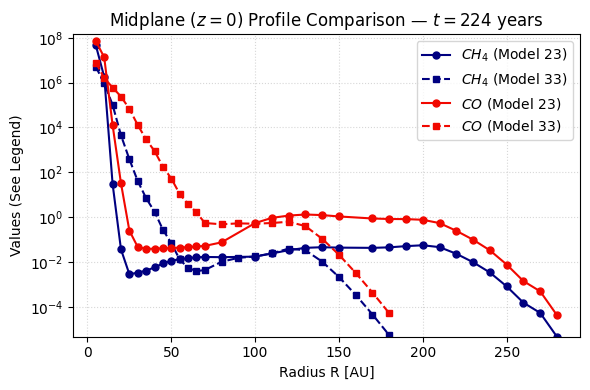

In [13]:
mplt.plot_midplane_nautilus_multi_comparison(PIPE,
                                       MODEL_NAMES,
                                       itime=i_last_time,
                                       MODE='chemistry',
                                       key_list=["CH4","CO"],
                                       fracab=False,
                                       verbose=True,
                                       xlim=None,
                                       ylim=None,
                                       colormap="jet",
                                       vmin=None,
                                       vmax=None,
                                        figsize=(6,4))


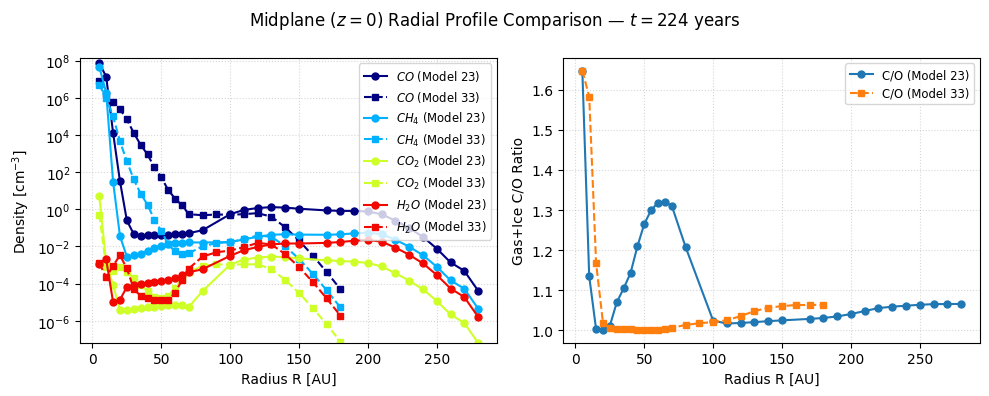

In [14]:
mplt.plot_midplane_nautilus_multi_CoverO(PIPE,
                                       MODEL_NAMES,
                                       itime=i_last_time,
                                       MODE='chemistry',
                                       species_list=["CO","CH4","CO2","H2O",],
                                       fracab=False,
                                       verbose=True,
                                       xlim=None,
                                       ylim=None,
                                       colormap="jet",
                                       vmin=None,
                                       vmax=None,
                                        figsize=(10,4
                                                ))

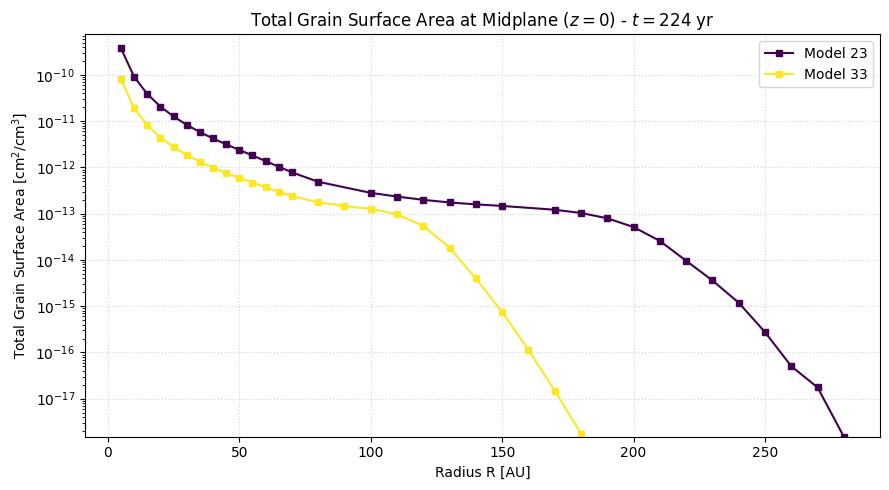

In [15]:
# TOTAL GRAIN SURFACE IN MIDPLANE
mplt.plot_grain_surface_midplane_comparison(PIPE,
                                      MODEL_NAMES,
                                      itime=i_last_time,
                                      verbose=True,
                                      xlim=None,
                                      ylim=None,
                                      colormap="viridis")

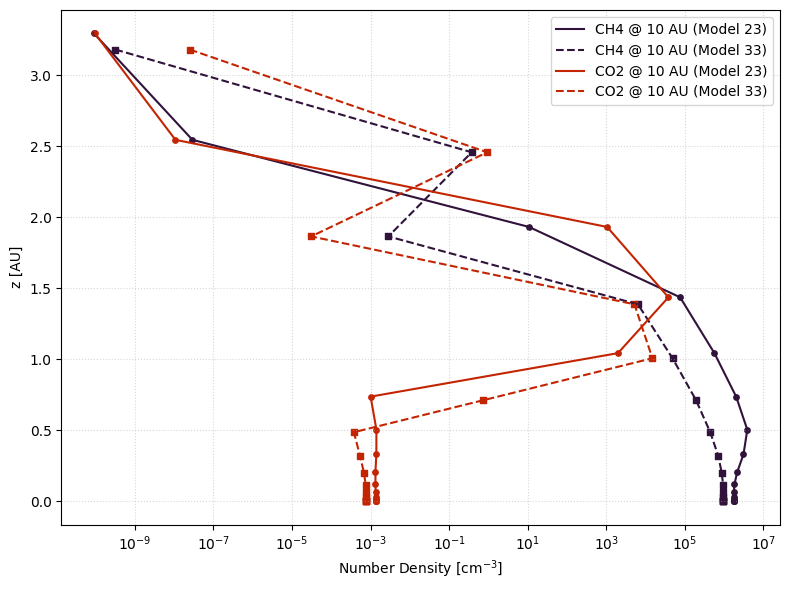

In [16]:
# SPECIES XX ABUNDANCE VERTICAL CUT
mplt.plot_vertical_cut_nautilus_comparison(PIPE,
                                     MODEL_NAMES,
                                     [10],
                                     species=['CH4','CO2'],
                                     itime=i_last_time,
                                     fracab=False,
                                     colormap="turbo",
                                     xlim=None,
                                     ylim=None,
                                     xscale="log",
                                     yscale="linear",
                                     verbose=True)           

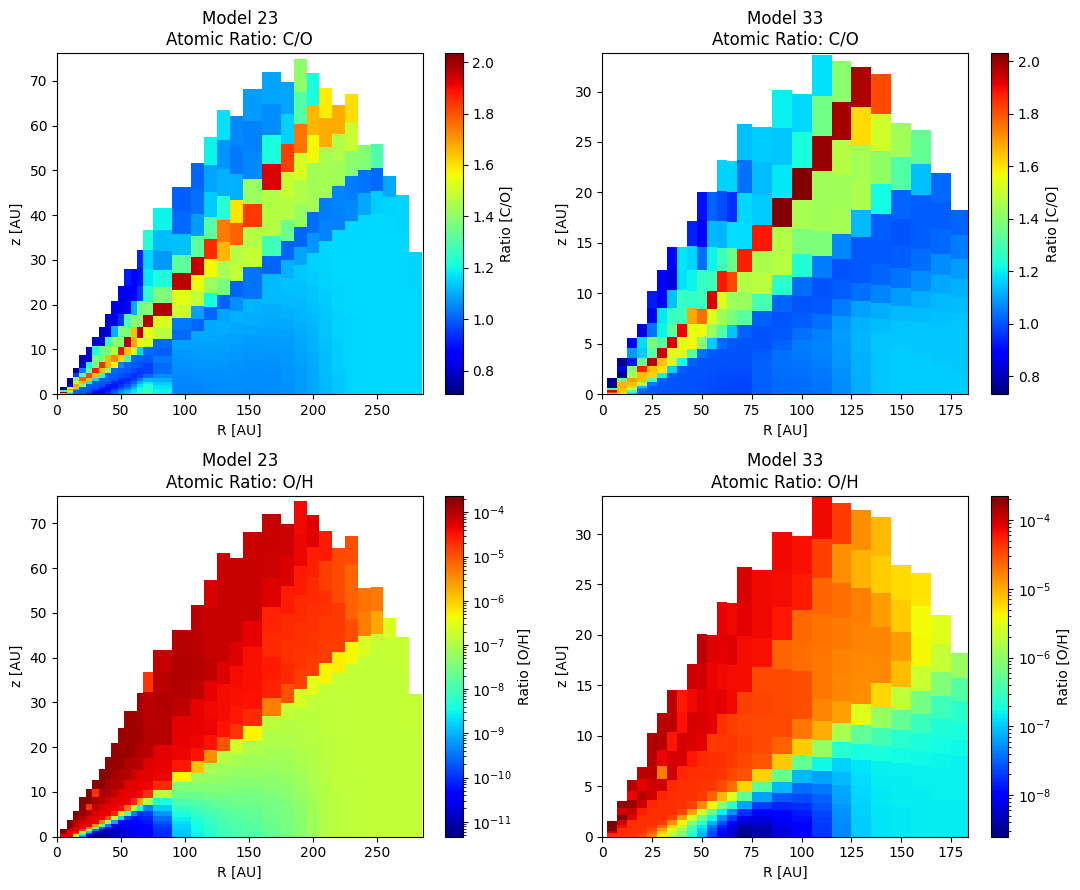

In [17]:
# ATOMIC RATIO 2D MAP
mplt.plot_atom_ratio_nautilus_comparison(PIPE,
                                   MODEL_NAMES,
                                   ratio_list=['C/O','O/H'],
                                   itime=i_last_time,
                                   verbose=True,
                                   xlim=None,
                                   ylim=None,
                                   colormap="jet",
                                   common_scale=False)

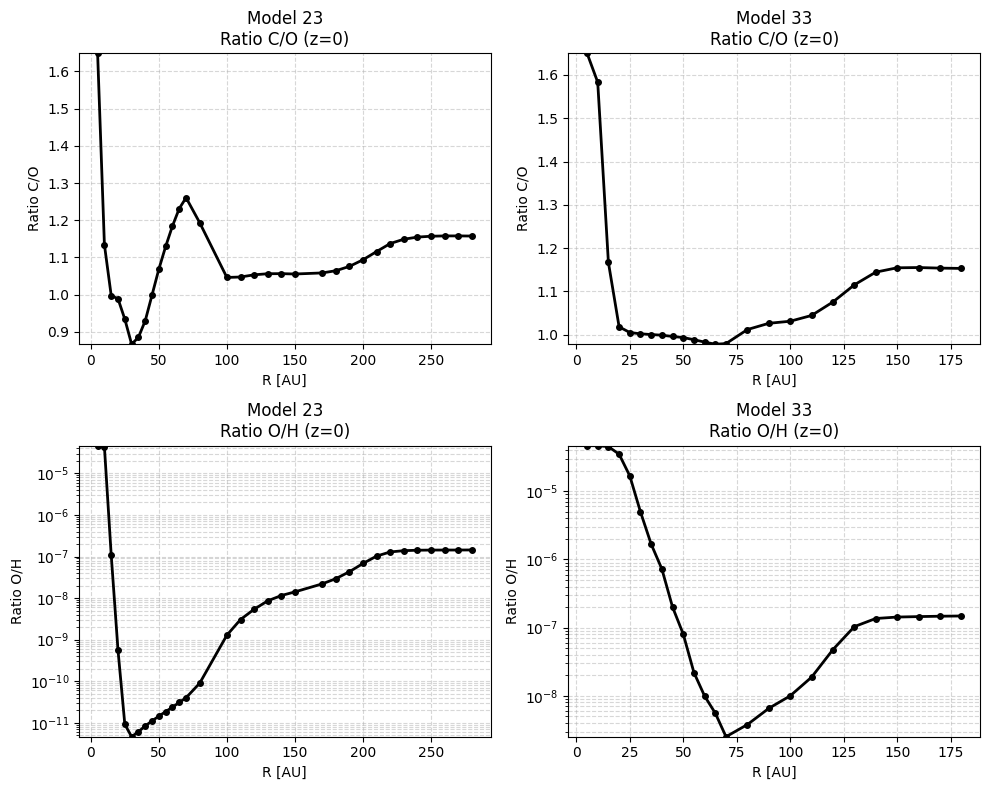

In [18]:
mplt.plot_atom_ratio_nautilus_midplane(PIPE,
                                     MODEL_NAMES,
                                     ratio_list=['C/O','O/H'],
                                     itime=i_last_time,
                                     verbose=True,
                                     xlim=None,
                                     ylim=None,
                                     common_scale=False)

In [19]:
chemistry_path = PIPE[-1].chempath
pip = PIPE[-1].chemistry

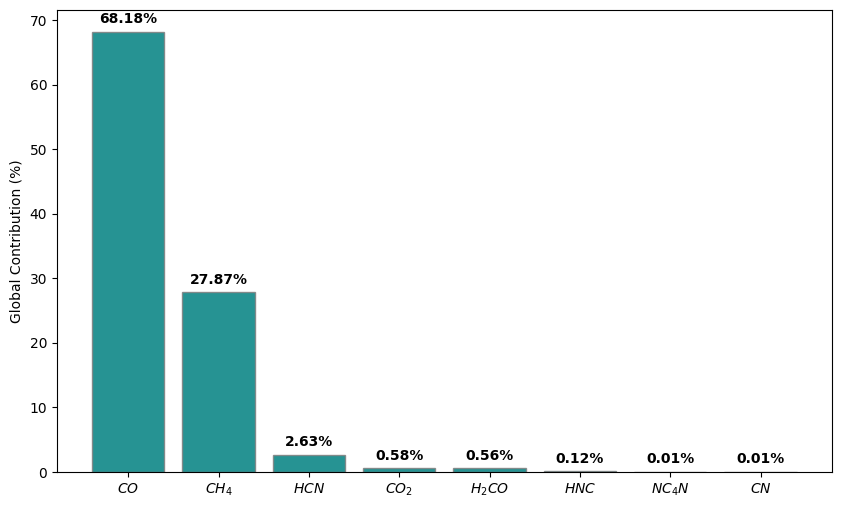

In [20]:
# TOP CONTRIBUTING SPECIES FOR X ATOM
mplt.plot_top_contributing_species(chempath=chemistry_path,
                                main_output_dict=pip,       
                                target_atom="C",     
                                itime=i_last_time,     
                                verbose=True,
                                spnumber=8,
                                color='teal',
                                phase="gas",
                                grain_bin=None)

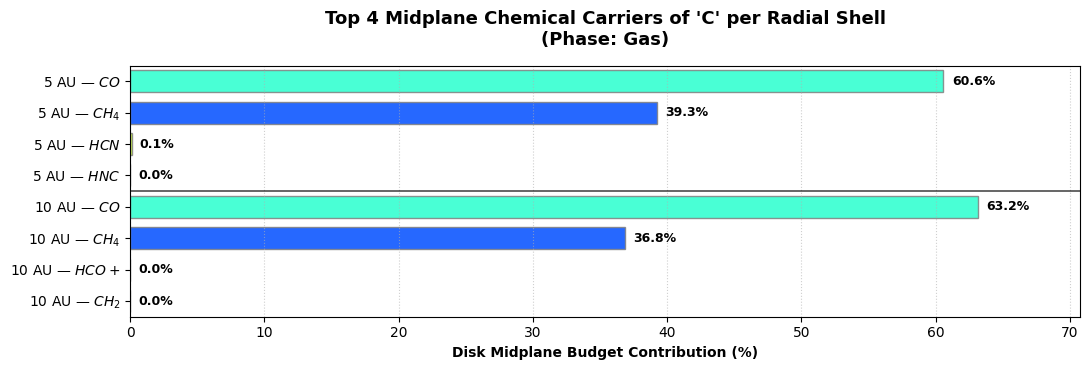

In [21]:
# TOP CONTRIBUTING SPECIES FOR X ATOM PER RADIUS IN MIDPLANE
mplt.plot_top_species_per_radius_midplane(chemistry_path,
                                 pip,
                                 target_atom="C",
                                 itime=i_last_time,
                                 verbose=True,
                                 spnumber=4,
                                 phase="gas",
                                 grain_bin=None,
                                 cmap_name="jet",
                                 rmin=None,
                                 rmax=10)

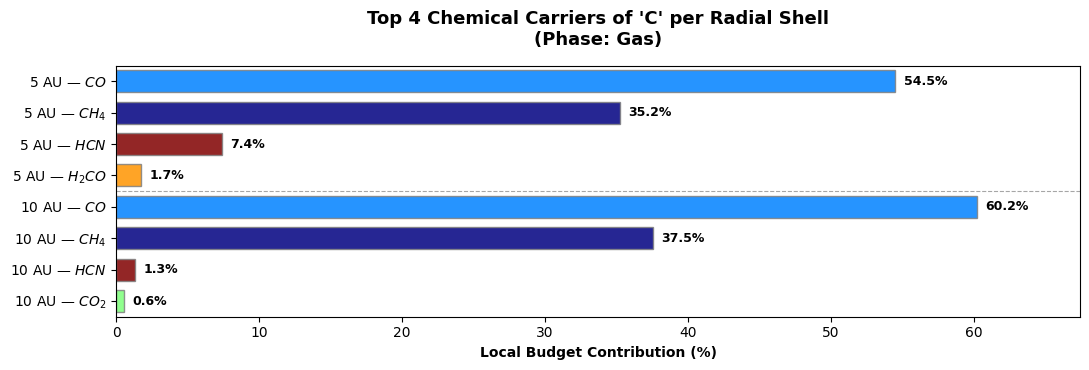

In [22]:
# TOP CONTRIBUTING SPECIES FOR X ATOM PER RADIUS IN MIDPLANE
mplt.plot_top_species_per_radius(chemistry_path,
                                 pip,
                                 target_atom="C",
                                 itime=i_last_time,
                                 verbose=True,
                                 spnumber=4,
                                 phase="gas",
                                 grain_bin=None,
                                 cmap_name="jet",
                                 rmin=None,
                                 rmax=10)

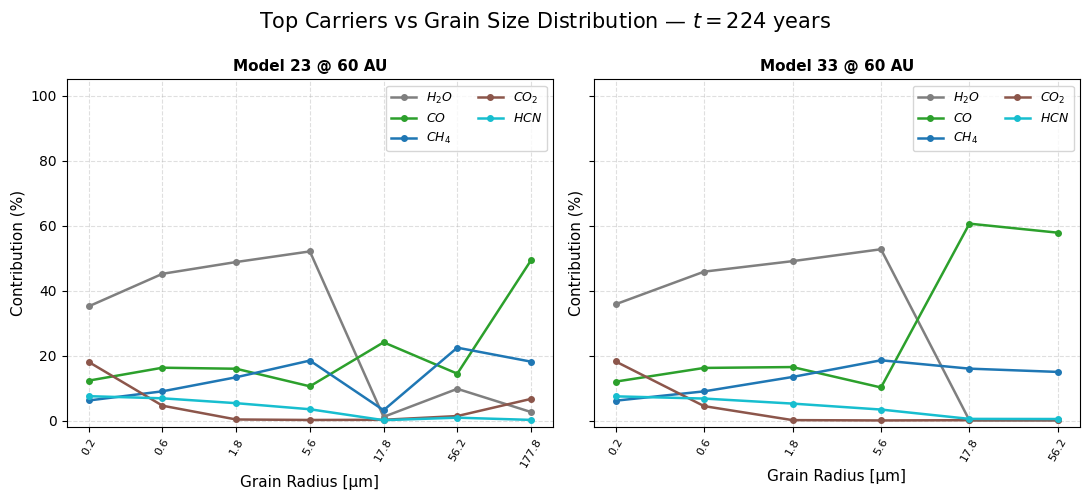

In [23]:
# TOP ICE SPECIES PER GRAIN SIZES
mplt.plot_species_evolution_with_grain_size_comparison(PIPE,
                                                 MODEL_NAMES,
                                                 [60],
                                                 itime=i_last_time,
                                                 verbose=True,
                                                 spnumber=5,
                                                 cmap_name="tab10")

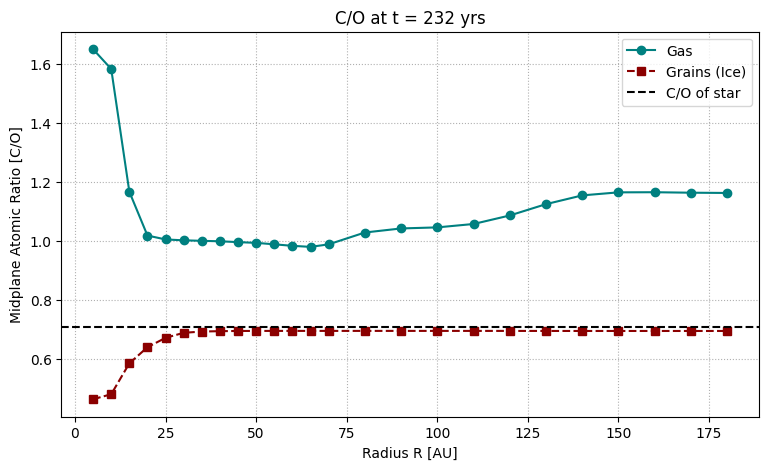

In [24]:
# ATOMIC RATIO AT MIDPLANE GAS VS. ICE
mplt.plot_ratio_midplane_gas_vs_grain(chemistry_path,
                                    pip,
                                    s1="C",
                                    s2="O",
                                    itime=i_last_time,
                                    starratio=0.7083,
                                    verbose=True,
                                    xlim=None,
                                    ylim=(0.8,2))

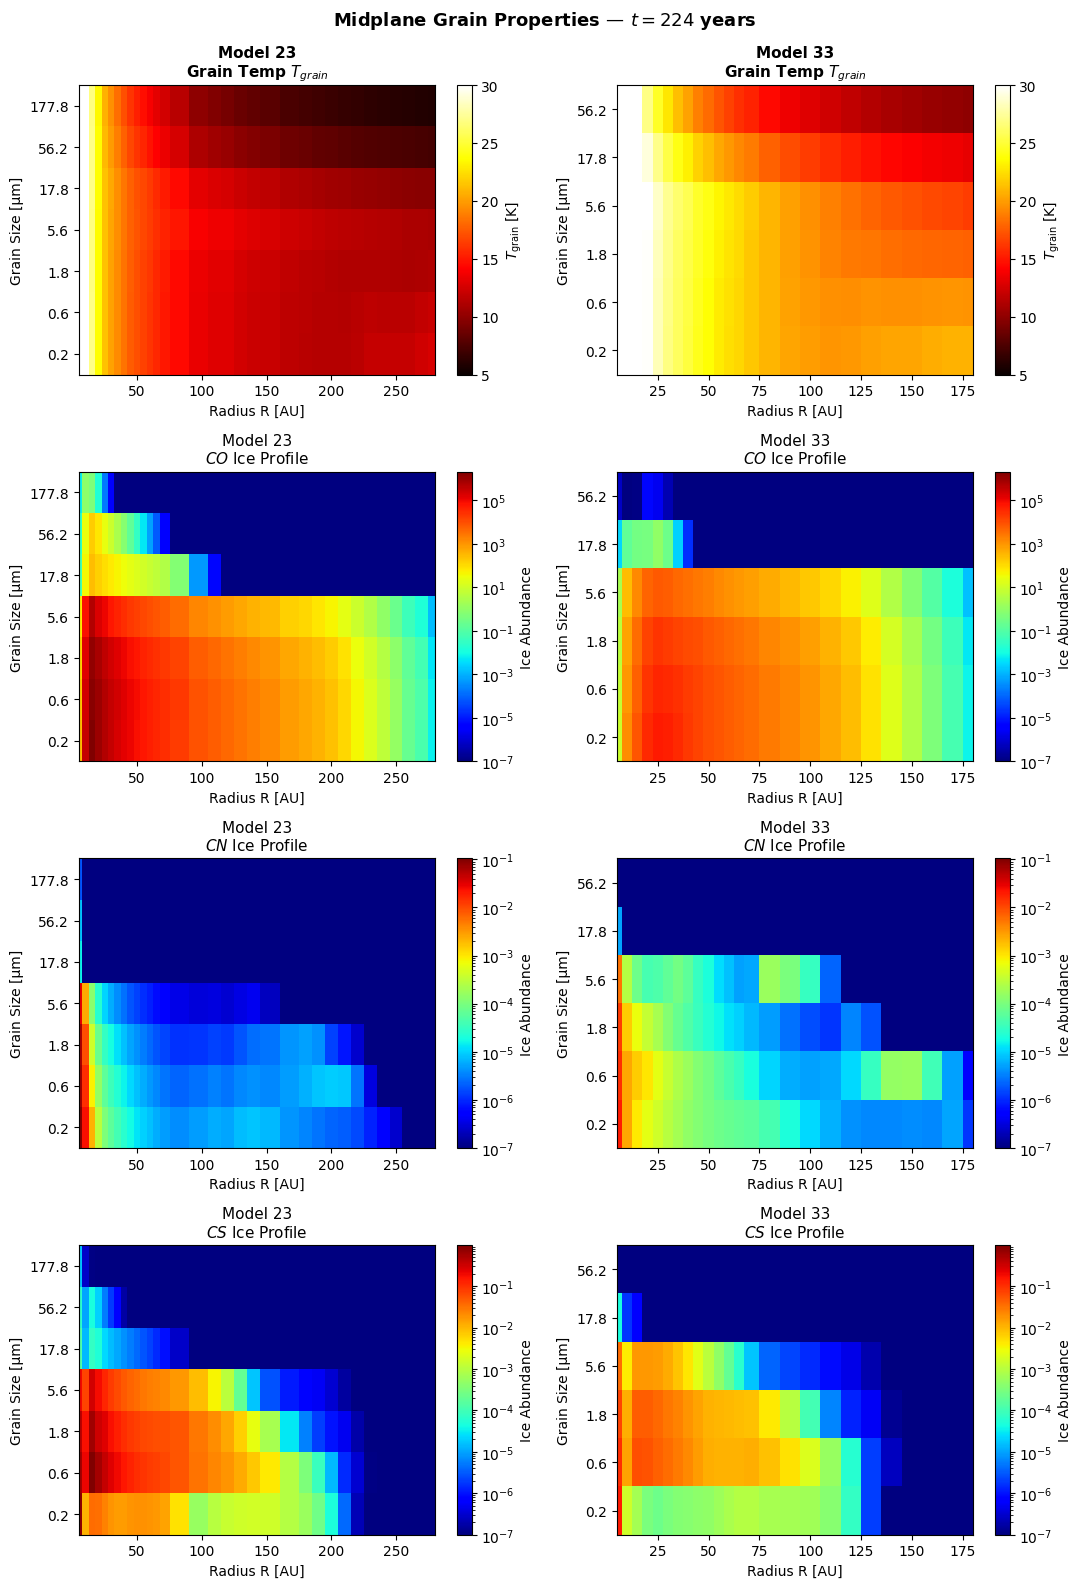

In [25]:
# GRAIN PROPERTIES IN MIDPLANE

mplt.plot_grain_properties_midplane_comparison(PIPE,
                                         MODEL_NAMES,
                                         key_list=["CO","CN","CS"],
                                          itime=i_last_time,
                                          fracab=False,
                                          verbose=True,
                                          xlim=None,
                                          ylim=None,
                                          Tmin=5,
                                          Tmax=30,
                                          temp_colormap='hot',
                                          ab_colormap='jet',
                                          common_scale=False,
                                         vmin=1e-7,
                                         vmax=None,
                                         species_scale_common=True)

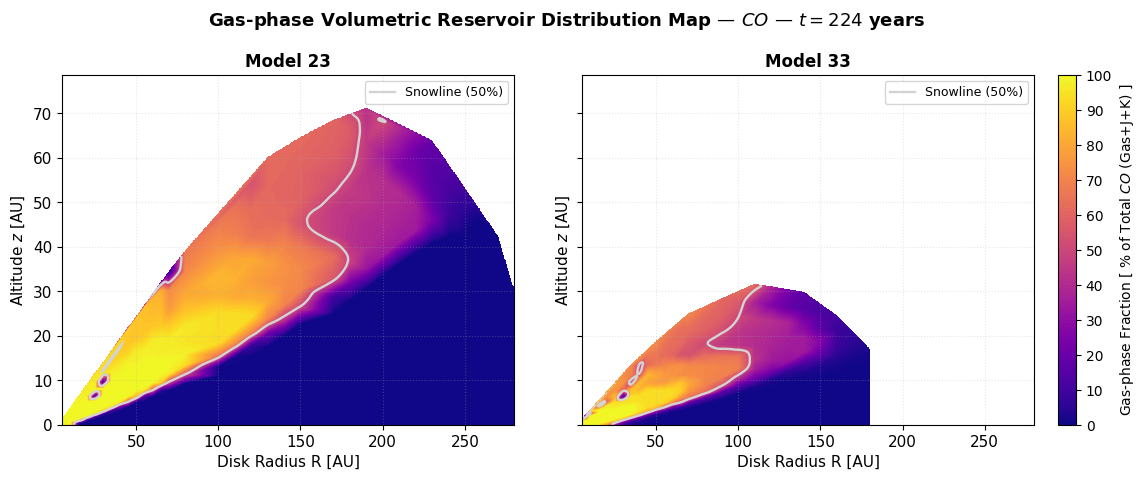

In [26]:
# SNOWLINE VISUALIZATION
mplt.plot_gas_fraction_map(PIPE,
                          MODEL_NAMES,
                          molecule="CO",
                          itime=i_last_time,
                          threshold=50,
                          overlay_color='lightgrey',
                          verbose=True,
                          xlim=None,
                          ylim=None,
                          rmin=None,
                          rmax=None,
                          colormap="plasma")

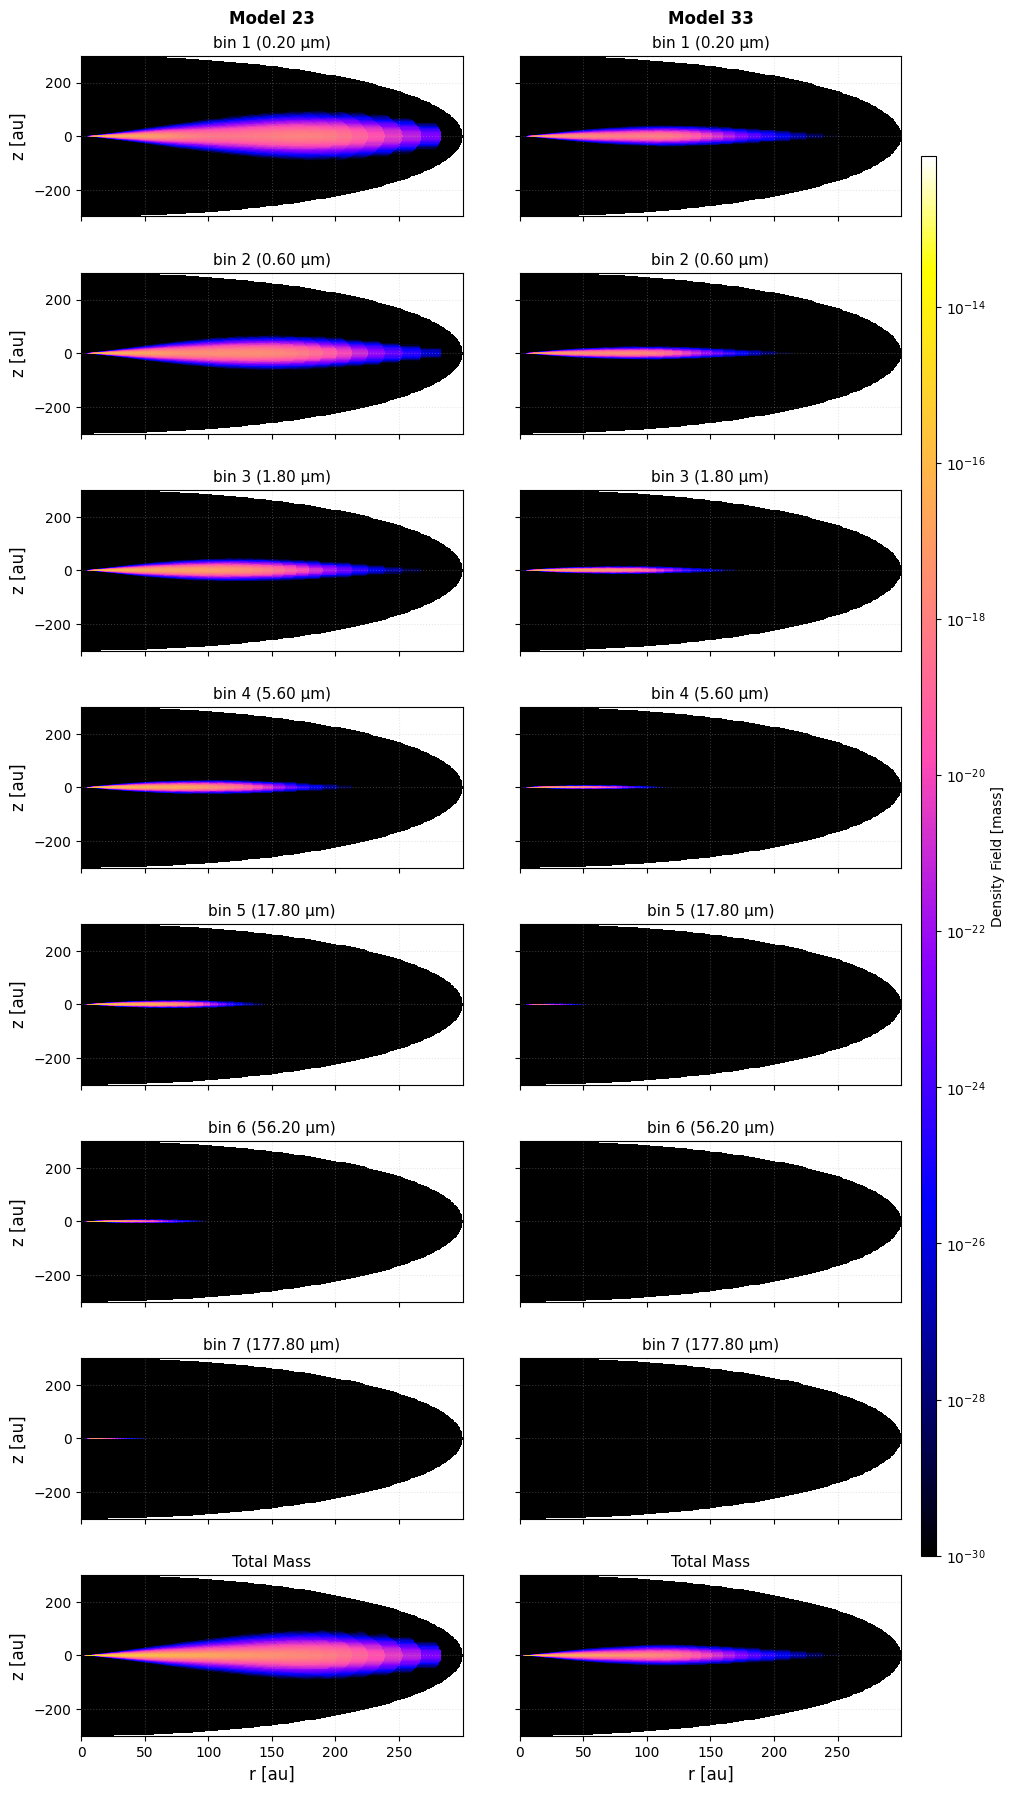

In [27]:
mplt.density2D_grid_comparison(PIPE,
                          MODEL_NAMES,
                          vmin=1e-30,
                          vmax=None,
                          cmap='gnuplot2',
                          dens_type='mass',
                          xlim=None,
                          ylim=None,
                          select_bins=[i for i in range(7)],
                         figsize=(10,20))

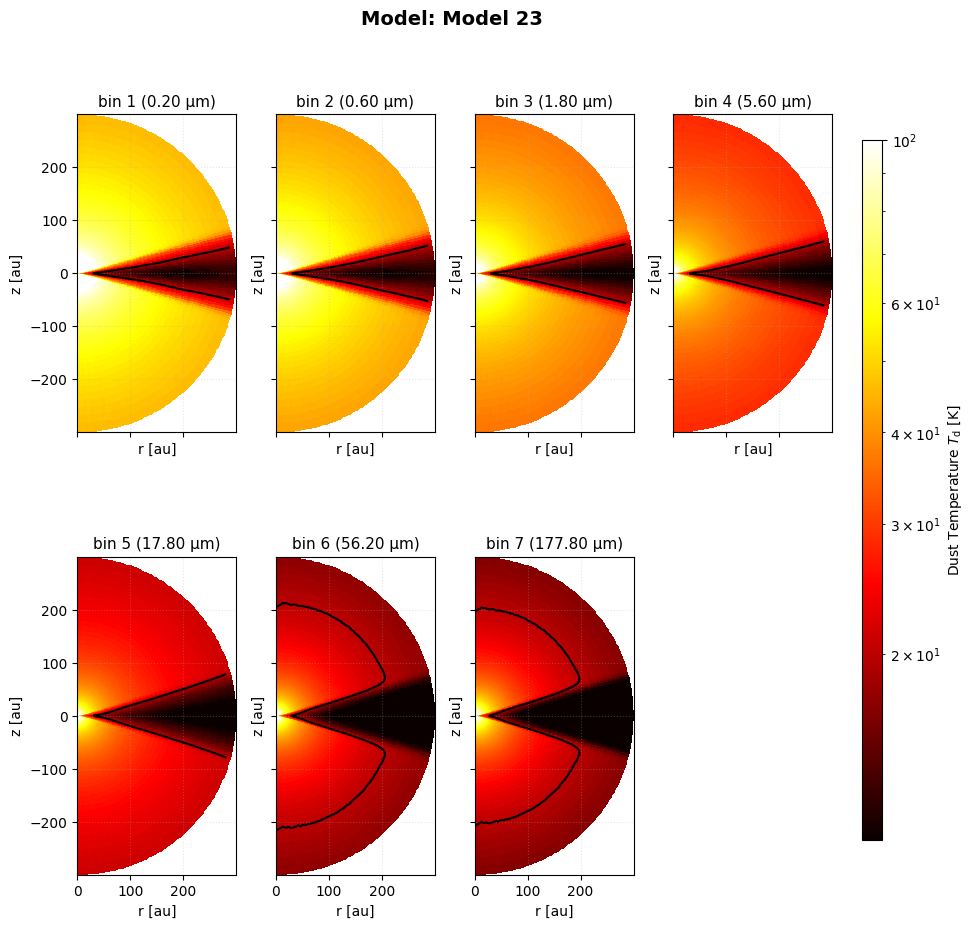

In [28]:
mplt.temperature2D_grid_comparison([PIPE[0]],
                             [MODEL_NAMES[0]],
                             vmin=None,
                             vmax=100,
                             cmap='hot',
                             xlim=None,
                             ylim=None,
                             snowline_temp=20.,
                              select_bins=[i for i in range(7)],
                             figsize=(10, 10), dust=None, log_scale=True)


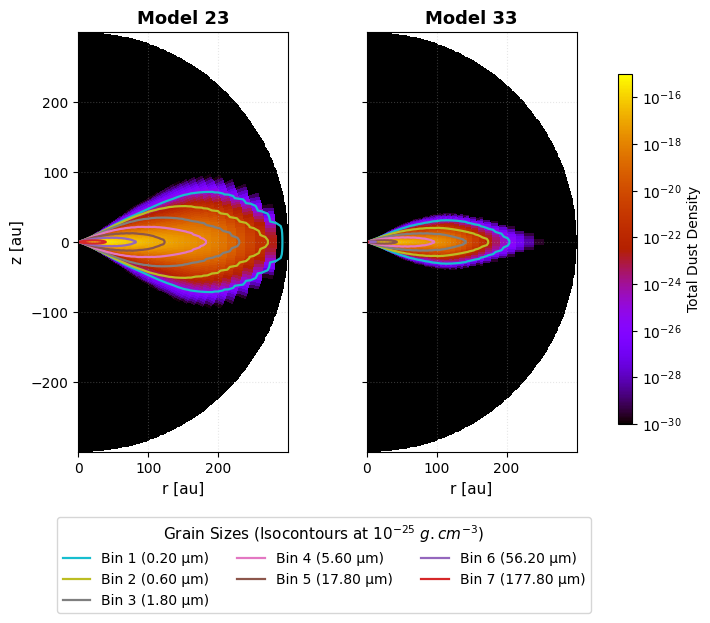

In [29]:
mplt.density2D_grid_comparison_contours(PIPE, MODEL_NAMES, vmin=1e-30, vmax=1e-15, cmap='gnuplot',
                             dens_type='mass', xlim=None, ylim=None, select_bins=[i for i in range(7)], 
                             figsize=(7,7), ndensity=1e-25)